In [2]:
import torch
import time
import numpy as np
import matplotlib.pyplot as plt

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}")
if torch.cuda.is_available():
    device = torch.device("cuda")
    device_name = torch.cuda.get_device_name(0)
    print(f"Using CUDA device: {device_name}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    device_name = "Apple Silicon (MPS)"
    print(f"Using MPS device: {device_name}")
else:
    device = torch.device("cpu")
    device_name = "CPU only"
    print("No GPU available, using CPU")
    print("WARNING: Please use Google Colab for this assignment!")

PyTorch version: 2.11.0+cu128
CUDA available: True
MPS available: False
Using CUDA device: Tesla T4


In [4]:
def create_matrices(size, device):
    A = torch.randn(size, size, device=device, dtype=torch.float32)
    B = torch.randn(size, size, device=device, dtype=torch.float32)
    return A, B

size = 1000
A_cpu, B_cpu = create_matrices(size, torch.device("cpu"))
print(f"Matrix A shape: {A_cpu.shape}")
print(f"Matrix A device: {A_cpu.device}")
print(f"Matrix A dtype: {A_cpu.dtype}")

Matrix A shape: torch.Size([1000, 1000])
Matrix A device: cpu
Matrix A dtype: torch.float32


In [5]:
def benchmark_matmul(A, B):
    device = A.device

    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()

    start = time.perf_counter()
    C = torch.mm(A, B)

    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()

    end = time.perf_counter()
    return (end - start) * 1000

In [6]:
sizes = [512, 1024, 2048, 4096, 8192]

results = {
    "sizes": sizes,
    "cpu_times": [],
    "gpu_times": [],
    "speedups": []
}

print("=" * 60)
print(f"{'Size':>8} | {'CPU (ms)':>12} | {'GPU (ms)':>12} | {'Speedup':>10}")
print("=" * 60)

for size in sizes:
    # CPU
    A_cpu, B_cpu = create_matrices(size, torch.device("cpu"))
    cpu_time = benchmark_matmul(A_cpu, B_cpu)

    # GPU
    A_gpu, B_gpu = create_matrices(size, device)
    gpu_time = benchmark_matmul(A_gpu, B_gpu)

    speedup = cpu_time / gpu_time

    results["cpu_times"].append(cpu_time)
    results["gpu_times"].append(gpu_time)
    results["speedups"].append(speedup)

    print(f"{size:>8} | {cpu_time:>10.2f}ms | {gpu_time:>10.2f}ms | {speedup:>9.2f}x")

print("=" * 60)

    Size |     CPU (ms) |     GPU (ms) |    Speedup
     512 |      37.51ms |     104.32ms |      0.36x
    1024 |      27.70ms |       1.24ms |     22.28x
    2048 |     177.44ms |       6.39ms |     27.76x
    4096 |    1653.79ms |      47.87ms |     34.55x
    8192 |    8658.47ms |     320.67ms |     27.00x


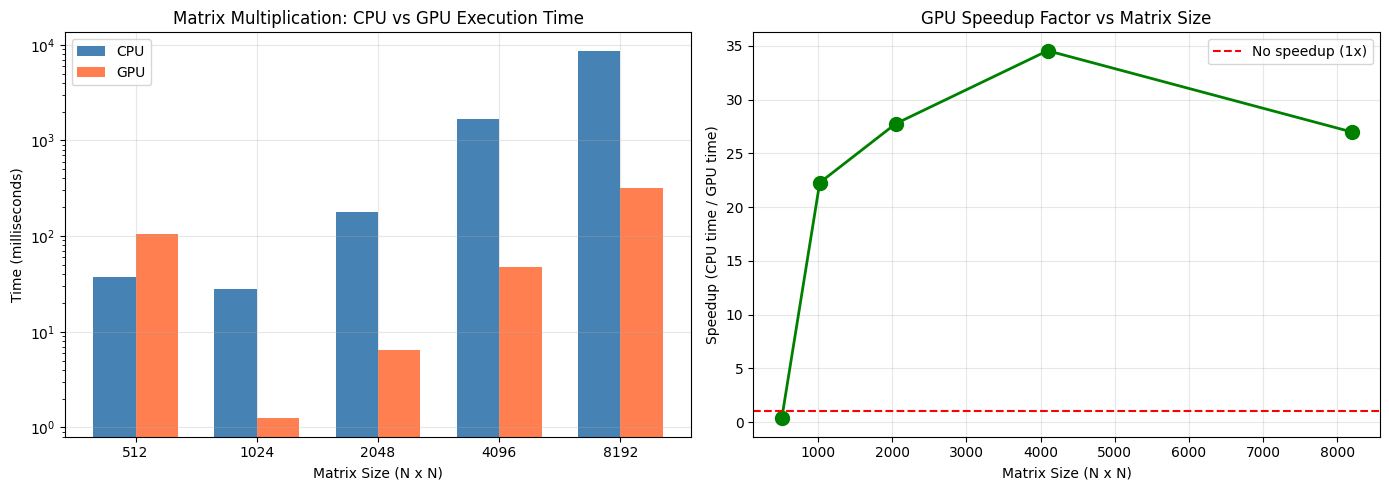

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
x = np.arange(len(sizes))
width = 0.35

bars1 = ax1.bar(x - width/2, results["cpu_times"], width,
                label='CPU', color='steelblue')
bars2 = ax1.bar(x + width/2, results["gpu_times"], width,
                label='GPU', color='coral')

ax1.set_xlabel('Matrix Size (N x N)')
ax1.set_ylabel('Time (milliseconds)')
ax1.set_title('Matrix Multiplication: CPU vs GPU Execution Time')
ax1.set_xticks(x)
ax1.set_xticklabels([str(s) for s in sizes])
ax1.legend()
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(sizes, results["speedups"], 'go-', linewidth=2, markersize=10)
ax2.axhline(y=1, color='r', linestyle='--', label='No speedup (1x)')
ax2.set_xlabel('Matrix Size (N x N)')
ax2.set_ylabel('Speedup (CPU time / GPU time)')
ax2.set_title('GPU Speedup Factor vs Matrix Size')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig('cpu_vs_gpu_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

## Part4: Analysis Questions
**Q1.The maximum speedup observed was 34.55x which occurred at the 4096 * 4096 matrix size.

**Q2.Because GPU computation is asynchronous.Specifically, after CPU issuesing the computing instruction to GPU, it won't wait GPU finish it. Thus, we need synchronize() to force the CPU wait for GPU's compution. If we removed it, the timing will usually become too short and inaccurate.

**Q3.In general, small matrix result smaller speedup, while large matrix result larger speedup. However, speedup didn't keep rising but peaked at around 4096, then flattened out or even fell back (it dropped at 8192).
I used an NVIDIA T4 GPU in Google Colab. The T4 has 2560 CUDA cores, 40 streaming multiprocessors, 16 GB of GDDR6 memory, and about 320 GB/s of memory bandwidth. These features allow the GPU to perform many matrix calculations in parallel. For smaller matrices, the GPU is not fully utilized and the overhead of launching GPU operations reduces its advantage. As the matrix size increases, more computations can be processed in parallel, so the GPU becomes much faster than the CPU.

**Q4. When GPU time smaller than CPU time, which is speedup larger than 1, GPU becomes worthwhile at approximately 1024 * 1024 matrix size. Because the time for GPU startup and data processing when dealing with small matrix will neutralize GPU computing advantage. Therefore, only dealing with the large matrix, GPU's advantage become obvious.

In [8]:
small_sizes = [16, 32, 64, 128, 192, 256, 384, 512, 768, 1024]

small_cpu_times = []
small_gpu_times = []
small_speedups = []

print(f"{'Size':>8} | {'CPU (ms)':>12} | {'GPU (ms)':>12} | {'Speedup':>10}")
print("=" * 55)

for size in small_sizes:
    # CPU
    A_cpu, B_cpu = create_matrices(size, torch.device("cpu"))
    cpu_time = benchmark_matmul(A_cpu, B_cpu)

    # GPU
    A_gpu, B_gpu = create_matrices(size, device)
    gpu_time = benchmark_matmul(A_gpu, B_gpu)

    # Speedup
    speedup = cpu_time / gpu_time

    small_cpu_times.append(cpu_time)
    small_gpu_times.append(gpu_time)
    small_speedups.append(speedup)

    print(f"{size:>8} | {cpu_time:>10.3f}ms | {gpu_time:>10.3f}ms | {speedup:>9.2f}x")

    Size |     CPU (ms) |     GPU (ms) |    Speedup
      16 |      4.178ms |     22.553ms |      0.19x
      32 |      0.102ms |      0.195ms |      0.52x
      64 |      0.069ms |      0.189ms |      0.37x
     128 |      0.127ms |      0.105ms |      1.22x
     192 |      0.305ms |      0.141ms |      2.17x
     256 |      0.644ms |     33.861ms |      0.02x
     384 |      1.944ms |      0.222ms |      8.74x
     512 |      3.856ms |      0.125ms |     30.96x
     768 |     11.868ms |      0.246ms |     48.32x
    1024 |     24.385ms |      0.445ms |     54.75x


# Bonus_Part_1:

The GPU took the lead for the first time around 128, but it didn't maintain a stable advantage until around 384. At size=256 the GPU time spiked to ~33.86ms, an outlier caused by on-off overhead instead of the size itself.

In [9]:
large_sizes = [16384, 20480, 28672, 36864]

large_cpu_times = []
large_gpu_times = []
large_speedups = []
successful_large_sizes = []

for size in large_sizes:
    try:
        print(f"\nTesting {size} x {size}...")

        # GPU
        A_gpu, B_gpu = create_matrices(size, device)
        gpu_time = benchmark_matmul(A_gpu, B_gpu)

        # CPU
        A_cpu, B_cpu = create_matrices(size, torch.device("cpu"))
        cpu_time = benchmark_matmul(A_cpu, B_cpu)


        speedup = cpu_time / gpu_time

        successful_large_sizes.append(size)
        large_cpu_times.append(cpu_time)
        large_gpu_times.append(gpu_time)
        large_speedups.append(speedup)

        print(f"CPU: {cpu_time:.2f} ms")
        print(f"GPU: {gpu_time:.2f} ms")
        print(f"Speedup: {speedup:.2f}x")

        # Clear memory
        del A_cpu, B_cpu, A_gpu, B_gpu
        torch.cuda.empty_cache()

    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print(f"Size {size}: Out of GPU memory")
            torch.cuda.empty_cache()
            break
        else:
            raise e


Testing 16384 x 16384...
CPU: 72945.01 ms
GPU: 2365.35 ms
Speedup: 30.84x

Testing 20480 x 20480...
CPU: 140947.36 ms
GPU: 4074.53 ms
Speedup: 34.59x

Testing 28672 x 28672...
CPU: 390842.40 ms
GPU: 12335.25 ms
Speedup: 31.69x

Testing 36864 x 36864...
Size 36864: Out of GPU memory


# Bonus_Part2
The maximum size that a GPU can be successfully run is 28,672. If we go up to the next level, 36864 will be out of memory. So the ceiling of T4 falls between 28,672 and 36,864.

When is super large, the speedup changes at 30.84 → 34.59 → 31.69, fluctuating between ~31-35x, and no longer increasing (20480 reaches the limit, 28672 drops a little). This is a diminishing return - extremely large matrices no longer provide a higher speedup ratio.

When GPU memory OOM occurred at 36864, it was caught by try/except → a prompt was printed + empty_cache() was called + the test was stopped with a break, and the program did not crash. However, in my first experiment, I recorded the situation where the CPU system RAM crashed for comparison - two memory extremes: GPU video memory OOM (which can be gracefully handled by try/except) vs CPU system RAM exhaustion (which directly causes the runtime to crash, cannot be handled directly, and can only be avoided by "not triggering")

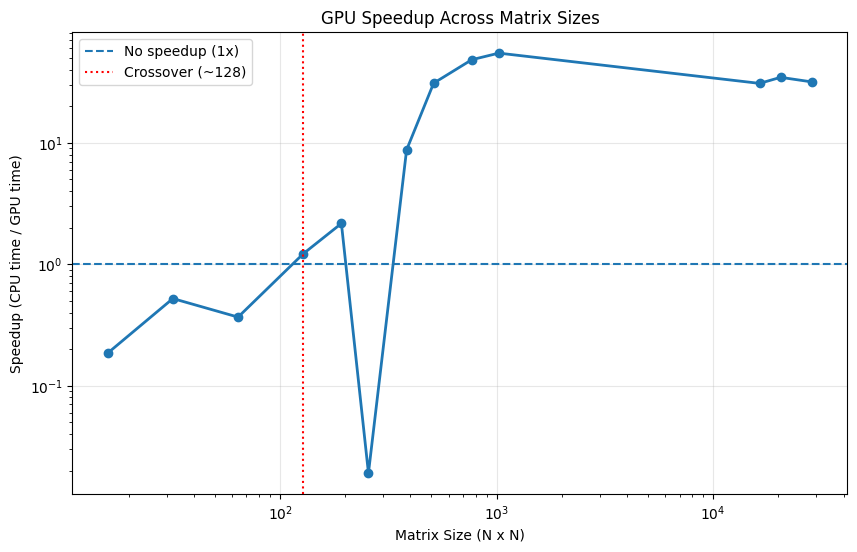

In [11]:
all_sizes = small_sizes + successful_large_sizes
all_speedups = small_speedups + large_speedups

plt.figure(figsize=(10, 6))

plt.plot(all_sizes, all_speedups, 'o-', linewidth=2)
plt.axhline(y=1, linestyle='--', label='No speedup (1x)')

plt.xscale('log')
plt.yscale('log')

plt.axvline(x=128, color='red', linestyle=':',
            label='Crossover (~128)')

plt.xlabel('Matrix Size (N x N)')
plt.ylabel('Speedup (CPU time / GPU time)')
plt.title('GPU Speedup Across Matrix Sizes')

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Bonus Analysis:
The crossover point was approximately 128 × 128, where the GPU speedup first became greater than 1.0x. For very small matrices, the speedup fluctuated because the computation time was very short, so GPU launch overhead and system timing variation had a larger effect. There was also an outlier at 256 × 256, where the GPU time was unusually high. After about 384 × 384, the speedup increased quickly because larger matrices could better use the GPU's parallel computing power. For very large matrices, the speedup began to level off and slightly decrease, showing diminishing returns as the GPU became highly utilized.